In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
df = pd.read_csv("../data/processed/clean_matches.csv")
df["date"] = pd.to_datetime(df["date"])
df["year"] = df["date"].dt.year

print(f"Loaded {len(df)} matches")
print(df.head())

Loaded 32314 matches
        date home_team  away_team  home_score  away_score tournament  \
0 1990-01-12   Algeria       Mali           5           0   Friendly   
1 1990-01-14   Algeria   Cameroon           3           1   Friendly   
2 1990-01-17    Greece    Belgium           2           0   Friendly   
3 1990-01-17    Mexico  Argentina           2           0   Friendly   
4 1990-01-20    Malawi   Tanzania           2           2   Friendly   

          city        country  neutral  year  month    result  
0        Paris         France     True  1990      1  Home Win  
1        Paris         France     True  1990      1  Home Win  
2       Athens         Greece    False  1990      1  Home Win  
3  Los Angeles  United States     True  1990      1  Home Win  
4      Lobamba      Swaziland     True  1990      1      Draw  


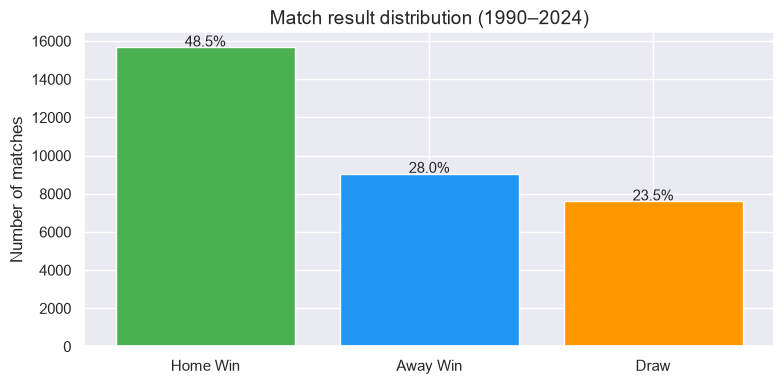

Home teams win more than away teams — this is home advantage in action


In [2]:

counts = df["result"].value_counts()
colors = ["#4CAF50", "#2196F3", "#FF9800"]

plt.figure(figsize=(8, 4))
bars = plt.bar(counts.index, counts.values, color=colors, edgecolor="white")
plt.title("Match result distribution (1990–2024)", fontsize=14)
plt.ylabel("Number of matches")

for bar, val in zip(bars, counts.values):
    pct = val / len(df)
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f"{pct:.1%}", ha="center", fontsize=11)
plt.tight_layout()
plt.show()

print("Home teams win more than away teams — this is home advantage in action")

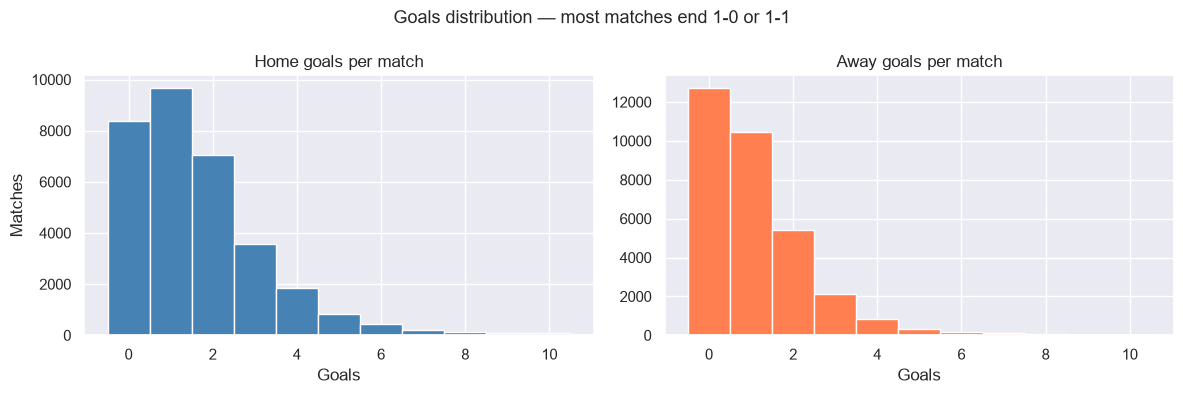

Average home goals: 1.65
Average away goals: 1.11
Home teams score more on average — further evidence of home advantage


In [3]:
# How many goals are scored per match?
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["home_score"], bins=range(0, 12), color="steelblue",
             edgecolor="white", align="left")
axes[0].set_title("Home goals per match")
axes[0].set_xlabel("Goals")
axes[0].set_ylabel("Matches")

axes[1].hist(df["away_score"], bins=range(0, 12), color="coral",
             edgecolor="white", align="left")
axes[1].set_title("Away goals per match")
axes[1].set_xlabel("Goals")

plt.suptitle("Goals distribution — most matches end 1-0 or 1-1", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Average home goals: {df['home_score'].mean():.2f}")
print(f"Average away goals: {df['away_score'].mean():.2f}")
print(f"Home teams score more on average — further evidence of home advantage")

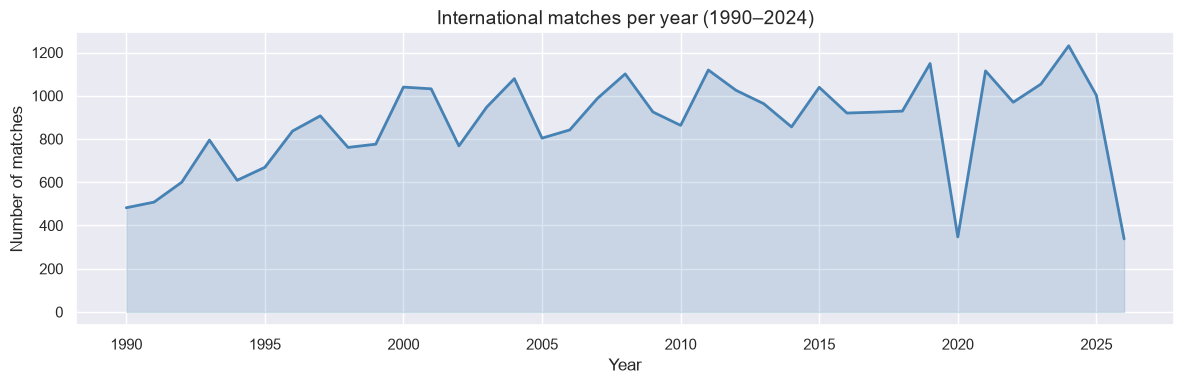

In [4]:
# Has the number of international matches grown over time?
matches_per_year = df.groupby("year").size()

plt.figure(figsize=(12, 4))
plt.plot(matches_per_year.index, matches_per_year.values,
         color="steelblue", linewidth=2)
plt.fill_between(matches_per_year.index, matches_per_year.values,
                 alpha=0.2, color="steelblue")
plt.title("International matches per year (1990–2024)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Number of matches")
plt.tight_layout()
plt.show()

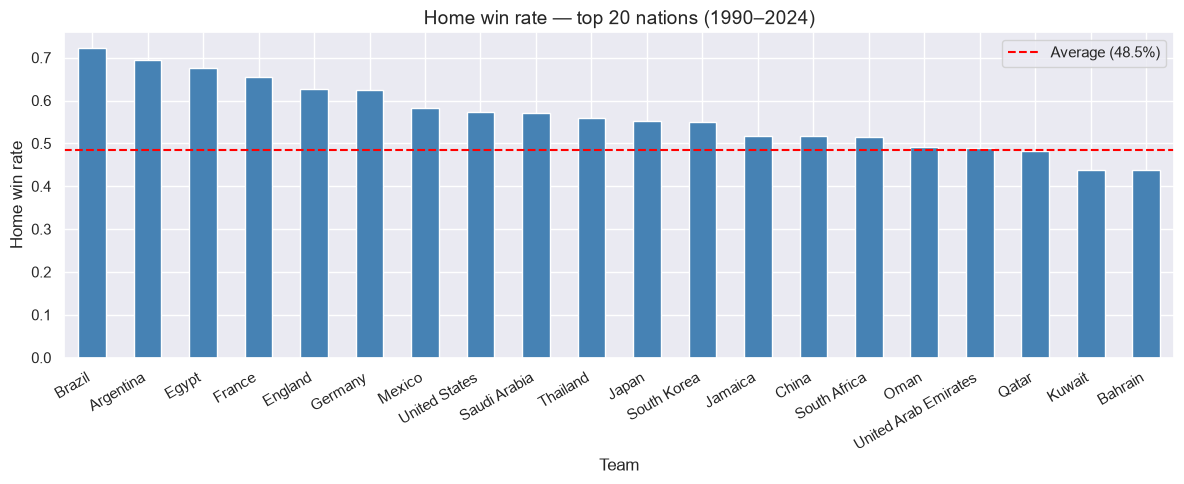

In [5]:
# Which teams have the best home win rate?
top_home_teams = df["home_team"].value_counts().head(20).index
df_top = df[df["home_team"].isin(top_home_teams)]

home_win_rate = (
    df_top[df_top["result"] == "Home Win"]
    .groupby("home_team").size() /
    df_top.groupby("home_team").size()
).sort_values(ascending=False)

plt.figure(figsize=(12, 5))
home_win_rate.plot(kind="bar", color="steelblue", edgecolor="white")
plt.axhline(df["result"].eq("Home Win").mean(), color="red",
            linestyle="--", label=f"Average ({df['result'].eq('Home Win').mean():.1%})")
plt.title("Home win rate — top 20 nations (1990–2024)", fontsize=14)
plt.xlabel("Team")
plt.ylabel("Home win rate")
plt.legend()
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()